# Road traffic deaths in the Canary Islands (1999–2023)

**Dataset**: Accidentes de circulación con víctimas mortales por lugar del accidente, provincias de Canarias

**Source**: [ISTAC](https://datos.canarias.es) — Instituto Canario de Estadística

**Question**: How has road mortality evolved in the two provinces of the Canary Islands (Las Palmas, S/C Tenerife)? Are urban or interurban roads more dangerous?

In [1]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
OUTPUT_DIR = Path("output/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 1. Load data ───────────────────────────────────────────────
# The CSV can be downloaded with:
#   python -m src.fetch --dataset accidentes-de-circulacion-con-victimas-mortales-por-lugar-del-accidente-provincias-de-canarias-1
# Or read directly from URL.

CSV_URL = (
    "https://datos.canarias.es/catalogos/general/dataset/838f82b4-7114-4209-869d-5bde1cea5b75"
    "/resource/e2d5b447-51f7-472f-a1dc-708fc2798615/download"
)
df = pd.read_csv(CSV_URL)

df.columns = df.columns.str.strip()
print(f"Rows: {len(df)} | Columns: {list(df.columns)}")
df.head(3)

Rows: 225 | Columns: ['anios', 'provincias_id', 'provincias_nombre', 'lugar_accidente_id', 'lugar_accidente_nombre', 'accidentes_circulacion_victimas_mortales', 'notas_observacion']


,anios,provincias_id,provincias_nombre,lugar_accidente_id,lugar_accidente_nombre,accidentes_circulacion_victimas_mortales,notas_observacion
0,1999,ES70,Canarias,T,TOTAL,160,NaN
1,1999,ES70,Canarias,A,Vías interurbanas,126,NaN
2,1999,ES70,Canarias,B,Vías urbanas,34,NaN


In [2]:
# ── 2. Normalize ───────────────────────────────────────────────

# Drop rows with missing numeric values ('..' means not available)
df["accidentes_circulacion_victimas_mortales"] = (
    pd.to_numeric(df["accidentes_circulacion_victimas_mortales"], errors="coerce")
)
df = df.dropna(subset=["accidentes_circulacion_victimas_mortales"])

df["anios"] = df["anios"].astype(int)

# Province mapping
prov_map = {"ES701": "Las Palmas", "ES702": "S/C Tenerife", "ES70": "Canarias"}
df["provincia"] = df["provincias_id"].map(prov_map)

# Road type
luogo_map = {"T": "Total", "A": "Interurban", "B": "Urban"}
df["road_type"] = df["lugar_accidente_id"].map(luogo_map)

print(df[["anios", "provincia", "road_type", "accidentes_circulacion_victimas_mortales"]].head(6))

   anios   provincia   road_type  accidentes_circulacion_victimas_mortales
0   1999    Canarias       Total                                     160.0
1   1999    Canarias  Interurban                                     126.0
2   1999    Canarias       Urban                                      34.0
3   1999  Las Palmas       Total                                     102.0
4   1999  Las Palmas  Interurban                                      81.0
5   1999  Las Palmas       Urban                                      21.0


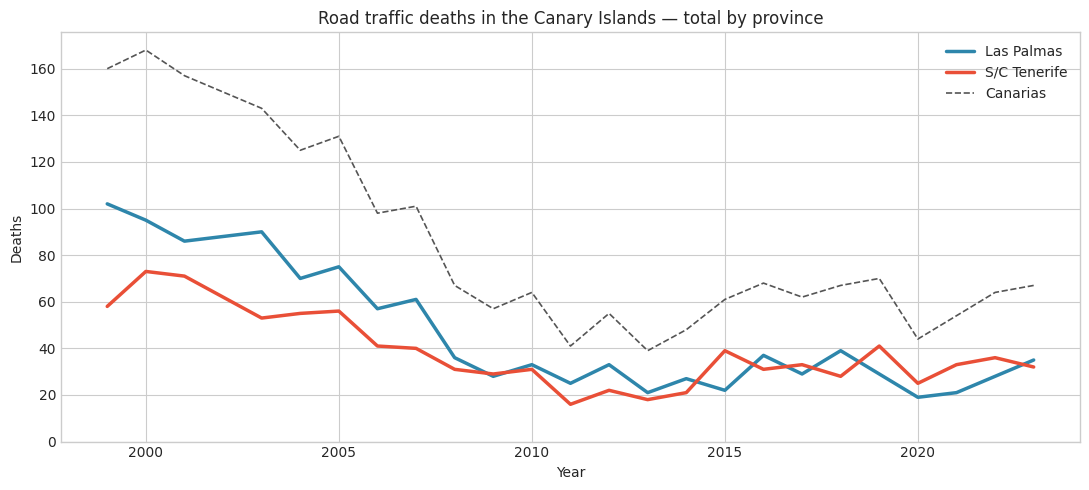

Saved: output/figures/trend_by_province.png


In [3]:
# ── 3. Historical trend — total per province ───────────────────

totale = df[df["road_type"] == "Total"].copy()

fig, ax = plt.subplots(figsize=(11, 5))

for prov, color in [("Las Palmas", "#2E86AB"), ("S/C Tenerife", "#E94F37"), ("Canarias", "#555555")]:
    d = totale[totale["provincia"] == prov].sort_values("anios")
    lw = 2.5 if prov != "Canarias" else 1.2
    ls = "-" if prov != "Canarias" else "--"
    ax.plot(d["anios"], d["accidentes_circulacion_victimas_mortales"],
            label=prov, color=color, linewidth=lw, linestyle=ls)

ax.set_xlabel("Year")
ax.set_ylabel("Deaths")
ax.set_title("Road traffic deaths in the Canary Islands — total by province")
ax.legend()
ax.set_ylim(0, None)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "trend_by_province.png", dpi=150)
plt.show()
print(f"Saved: {OUTPUT_DIR / 'trend_by_province.png'}")

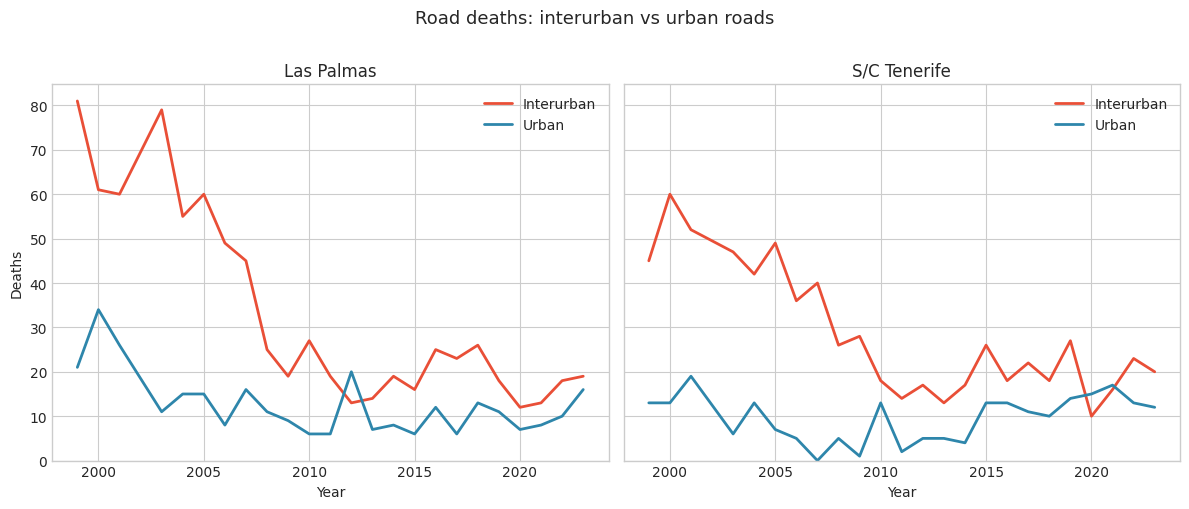

Saved: output/figures/interurban_vs_urban.png


In [4]:
# ── 4. Interurban vs Urban — historical comparison ──────────────

colors = {"Interurban": "#E94F37", "Urban": "#2E86AB"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, prov in zip(axes, ["Las Palmas", "S/C Tenerife"]):
    for tipo, color in colors.items():
        d = df[(df["provincia"] == prov) & (df["road_type"] == tipo)].sort_values("anios")
        ax.plot(d["anios"], d["accidentes_circulacion_victimas_mortales"],
                label=tipo, color=color, linewidth=2)
    ax.set_title(prov)
    ax.set_xlabel("Year")
    ax.set_ylim(0, None)
    ax.legend()

axes[0].set_ylabel("Deaths")
fig.suptitle("Road deaths: interurban vs urban roads", fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "interurban_vs_urban.png", dpi=150)
plt.show()
print(f"Saved: {OUTPUT_DIR / 'interurban_vs_urban.png'}")

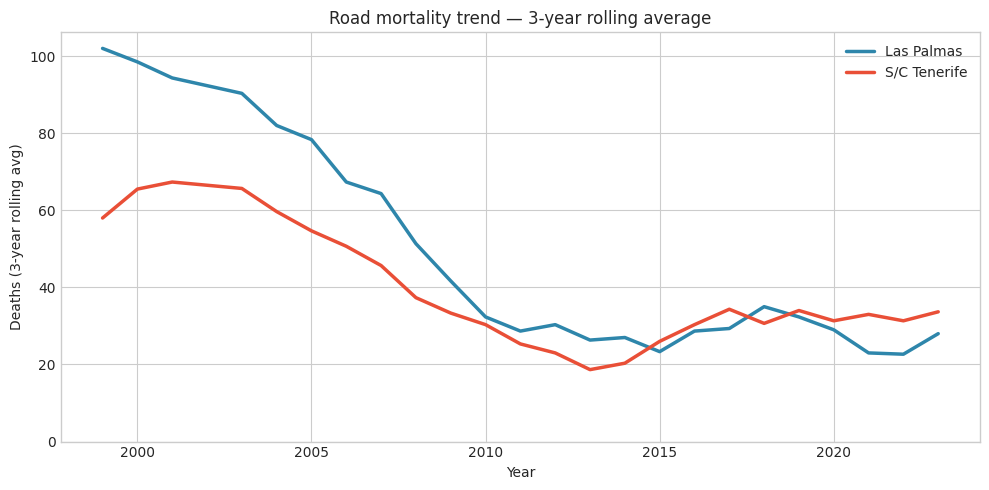

Saved: output/figures/rolling_avg_3yr.png


In [5]:
# ── 5. 3-year rolling average — provincial trend ───────────────

def rolling_avg(series, window=3):
    return series.rolling(window, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(10, 5))

for prov, color in [("Las Palmas", "#2E86AB"), ("S/C Tenerife", "#E94F37")]:
    d = totale[totale["provincia"] == prov].sort_values("anios").set_index("anios")
    ax.plot(d.index, rolling_avg(d["accidentes_circulacion_victimas_mortales"]),
            label=prov, color=color, linewidth=2.5)

ax.set_xlabel("Year")
ax.set_ylabel("Deaths (3-year rolling avg)")
ax.set_title("Road mortality trend — 3-year rolling average")
ax.legend()
ax.set_ylim(0, None)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "rolling_avg_3yr.png", dpi=150)
plt.show()
print(f"Saved: {OUTPUT_DIR / 'rolling_avg_3yr.png'}")

In [6]:
# ── 6. Numeric summary ──────────────────────────────────────────

summary = (
    totale.groupby("provincia")["accidentes_circulacion_victimas_mortales"]
    .agg(["sum", "mean", "max"])
    .rename(columns={"sum": "Total deaths", "mean": "Yearly avg", "max": "Peak"})
)

print("Summary 1999–2023:")
print(summary.round(1))

Summary 1999–2023:
              Total deaths  Yearly avg   Peak
provincia                                    
Canarias            2011.0        83.8  168.0
Las Palmas          1098.0        45.8  102.0
S/C Tenerife         913.0        38.0   73.0
